In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

In [2]:
# --- 1. Configuración y Carga de Datos ---
class UrbanSafetyDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        """
        Args:
            csv_file (string): Ruta al csv con scores y coverage.
            img_dir (string): Carpeta con las imágenes .jpg o .png
        """
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        # Cargar Imagen
        img_name = str(row['ImageName']) + ".jpg" # Asumiendo formato jpg
        img_path = os.path.join(self.img_dir, img_name)
        
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            # Si no encuentra la imagen, crea una negra (para evitar crash en pruebas)
            image = Image.new('RGB', (224, 224))
            
        if self.transform:
            image = self.transform(image)
            
        # Cargar Datos Extra (Coverage, Entropy, etc.)
        # Normalizamos dividiendo por un máximo teórico (ej. 100) o estandarizando antes
        meta_data = torch.tensor([row['saliency_coverage']], dtype=torch.float32)
        
        # Score (Target)
        score = torch.tensor([row['score']], dtype=torch.float32)
        
        return image, meta_data, score, img_name

In [3]:


# --- 2. Definición del Modelo Multimodal ---
class SafetyHybridModel(nn.Module):
    def __init__(self):
        super(SafetyHybridModel, self).__init__()
        
        # A. Rama de Imagen (ResNet50)
        resnet = models.resnet50(pretrained=True)
        
        # Separamos las capas para poder acceder a la última convolución (layer4) para GradCAM
        self.features_conv = nn.Sequential(*list(resnet.children())[:-2]) # Hasta el último bloque conv
        self.avgpool = resnet.avgpool
        
        # B. Rama de Metadatos (Coverage)
        self.meta_fc = nn.Sequential(
            nn.Linear(1, 16), # Entrada: 1 variable (Coverage)
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU()
        )
        
        # C. Fusión y Predicción
        # Resnet50 saca 2048 features + 32 de metadata
        self.regressor = nn.Sequential(
            nn.Linear(2048 + 32, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 1) # Salida: Score (1-10)
        )
        
        # Placeholder para los gradientes (GradCAM)
        self.gradients = None

    # Hook para capturar gradientes en el backward pass
    def activations_hook(self, grad):
        self.gradients = grad

    def forward(self, x_img, x_meta):
        # 1. Imagen
        x = self.features_conv(x_img)
        
        # Registramos el hook si estamos en modo entrenamiento o evaluacion con gradientes
        if x.requires_grad:
            h = x.register_hook(self.activations_hook)
            
        # Guardamos las activaciones para GradCAM
        self.current_activations = x 
        
        x = self.avgpool(x)
        x = torch.flatten(x, 1) # (Batch, 2048)
        
        # 2. Metadata
        m = self.meta_fc(x_meta) # (Batch, 32)
        
        # 3. Concatenar
        combined = torch.cat((x, m), dim=1)
        
        # 4. Predicción
        score = self.regressor(combined)
        return score

    # Función para generar el mapa de calor
    def get_gradcam_heatmap(self):
        # Tomar los gradientes y activaciones guardados
        gradients = self.gradients.cpu().data.numpy()
        activations = self.current_activations.cpu().data.numpy()
        
        # Global Average Pooling de los gradientes
        weights = np.mean(gradients, axis=(2, 3))[0, :]
        
        # Mapa de características (primera imagen del batch)
        cam = np.zeros(activations.shape[2:], dtype=np.float32)
        
        for i, w in enumerate(weights):
            cam += w * activations[0, i, :, :]
            
        # ReLU (solo nos interesan las contribuciones positivas a la seguridad)
        cam = np.maximum(cam, 0)
        
        # Normalizar 0-1
        cam = cv2.resize(cam, (224, 224))
        cam = cam - np.min(cam)
        cam = cam / np.max(cam)
        return cam



In [6]:
# --- 3. Script Principal ---
def run_experiment():
    # Setup
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Cargar Dataset (Ajusta la ruta de tus imágenes)
    dataset = UrbanSafetyDataset('precalculated_saliency_coverage.csv','static/images/images/images', transform)
    dataloader = DataLoader(dataset, batch_size=16, shuffle=True)
    
    # Inicializar Modelo
    model = SafetyHybridModel()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    criterion = nn.MSELoss() # Usamos Error Cuadrático para predecir el Score exacto
    
    # --- Loop de Entrenamiento (Simplificado) ---
    print("Iniciando Entrenamiento...")
    model.train()
    for epoch in range(5): # 5 Epocas de prueba
        total_loss = 0
        for imgs, metas, scores, _ in dataloader:
            optimizer.zero_grad()
            outputs = model(imgs, metas)
            loss = criterion(outputs, scores)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {total_loss/len(dataloader):.4f}")
    
    # --- Inferencia y GradCAM ---
    print("\nGenerando GradCAM para una muestra...")
    model.eval()
    
    # Tomamos una imagen del dataset
    img, meta, score_real, img_name = dataset[0] 
    img = img.unsqueeze(0) # Batch size 1
    meta = meta.unsqueeze(0)
    
    # Importante: Para GradCAM necesitamos gradientes aunque estemos en eval
    img.requires_grad = True 
    
    # Forward Pass
    score_pred = model(img, meta)
    
    # Backward Pass (para calcular qué partes de la imagen activaron ese score)
    model.zero_grad()
    score_pred.backward()
    
    # Obtener Heatmap
    heatmap = model.get_gradcam_heatmap()
    
    # Clasificación Final
    pred_val = score_pred.item()
    clase = "SEGURO" if pred_val > 5 else "NO SEGURO"
    
    print(f"Imagen: {img_name}")
    print(f"Score Real: {score_real.item()}")
    print(f"Score Predicho: {pred_val:.2f} -> Clasificación: {clase}")
    
    # Visualizar (Si estás en local)
    plt.imshow(heatmap, cmap='jet')
    plt.title(f"GradCAM: Qué miró el modelo ({clase})")
    plt.show()



c:\Users\vdela\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\vdela\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Iniciando Entrenamiento...
Epoch 1, Loss: 5.4490
Epoch 2, Loss: 4.2193
Epoch 3, Loss: 4.2565
Epoch 4, Loss: 4.1998
Epoch 5, Loss: 4.3305

Generando GradCAM para una muestra...
Imagen: 3.0.jpg
Score Real: 7.0
Score Predicho: 5.27 -> Clasificación: SEGURO


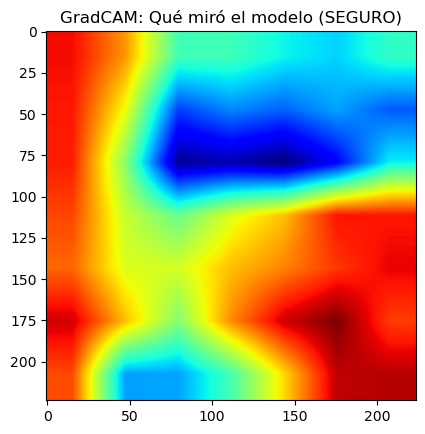

In [7]:
# Para ejecutar (descomentar si tienes las librerías y datos)
run_experiment()

In [5]:
# Para ejecutar (descomentar si tienes las librerías y datos)
run_experiment()

c:\Users\vdela\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\vdela\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\vdela/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:41<00:00, 2.48MB/s]


Iniciando Entrenamiento...
Epoch 1, Loss: 5.1027
Epoch 2, Loss: 4.1425
Epoch 3, Loss: 4.1706


KeyboardInterrupt: 